# Этап 1: Исследовательский анализ данных (EDA) и проверка бизнес-гипотез
Наша цель — проанализировать исходные кадастровые данные, выявить физические аномалии (например, Лахта Центр) и доказать наличие систематических ошибок в государственной разметке, чтобы обосновать выбор признаков для алгоритма.

Посмотрим на наши исходные датасеты

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from folium.plugins import HeatMap

sns.set_theme(style="whitegrid")

In [7]:
df_B = pd.read_csv('data/raw/cup_it_example_src_B.csv')
df_B.head()

C:\Users\User\AppData\Local\Temp\ipykernel_19264\4074460171.py:1: DtypeWarning: Columns (0: fraction) have mixed types. Specify dtype option on import or set low_memory=False.
  df_B = pd.read_csv('data/raw/cup_it_example_src_B.csv')


,Unnamed: 0,subject,district,type,locality,type_street,name_street,number,letter,fraction,housing,building,purpose_of_building,stairs,avg_floor_height,height,wkt,id
0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,4.5,MULTIPOLYGON (((30.095068678257853 59.84887228...,1
1,1,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,4.5,MULTIPOLYGON (((30.278318962652364 59.96375009...,2
2,2,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,28.0,MULTIPOLYGON (((30.29715832931408 60.012659308...,3
3,3,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,23.0,MULTIPOLYGON (((30.29741936528335 59.977966278...,4
4,4,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,49.0,MULTIPOLYGON (((30.306284394781 59.89648495498...,5



 Анализ: Источник А
Строк: 171454
Столбцов: 9

Типы данных и память
<class 'pandas.DataFrame'>
RangeIndex: 171454 entries, 0 to 171453
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Unnamed: 0           171454 non-null  int64  
 1   id                   171454 non-null  int64  
 2   title                7357 non-null    str    
 3   tags                 171454 non-null  str    
 4   geometry             171454 non-null  str    
 5   area_sq_m            171454 non-null  float64
 6   gkh_address          18239 non-null   str    
 7   gkh_floor_count_min  17293 non-null   float64
 8   gkh_floor_count_max  17632 non-null   float64
dtypes: float64(3), int64(2), str(4)
memory usage: 11.8 MB
None

 Пропущенные значения (NaN)
                      Count  Percent %
title                164097  95.709053
gkh_floor_count_min  154161  89.913913
gkh_floor_count_max  153822  89.716192
gkh_address          1

C:\Users\User\AppData\Local\Temp\ipykernel_19264\2133177291.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nan_percent.values, y=nan_percent.index, palette='magma')


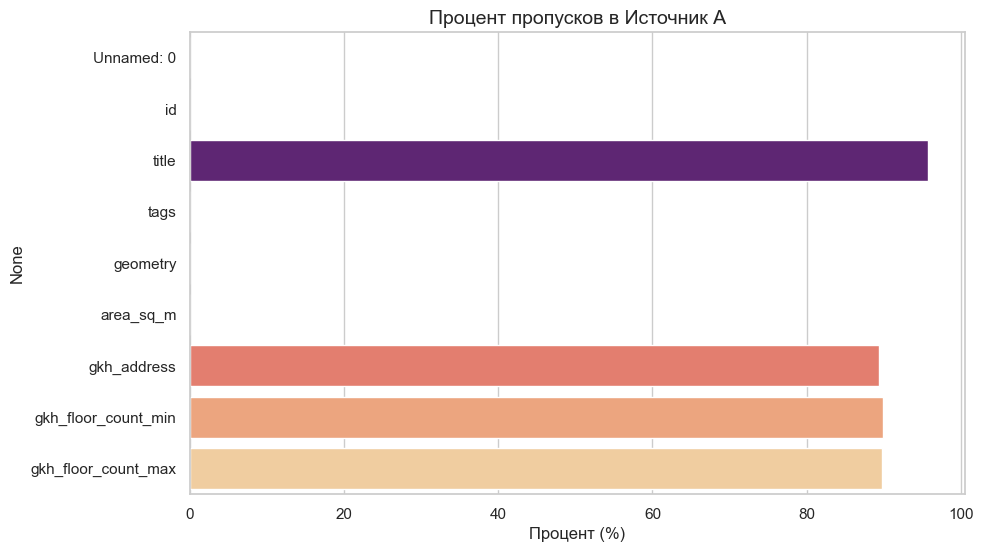


 Анализ: Источник Б
Строк: 161076
Столбцов: 18

Типы данных и память
<class 'pandas.DataFrame'>
RangeIndex: 161076 entries, 0 to 161075
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Unnamed: 0           161076 non-null  int64  
 1   subject              156816 non-null  str    
 2   district             157091 non-null  str    
 3   type                 156189 non-null  str    
 4   locality             155903 non-null  str    
 5   type_street          88012 non-null   str    
 6   name_street          88029 non-null   str    
 7   number               161076 non-null  int64  
 8   letter               8735 non-null    str    
 9   fraction             1098 non-null    object 
 10  housing              30536 non-null   str    
 11  building             273 non-null     float64
 12  purpose_of_building  157112 non-null  str    
 13  stairs               157075 non-null  float64
 14  avg_floor

C:\Users\User\AppData\Local\Temp\ipykernel_19264\2133177291.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nan_percent.values, y=nan_percent.index, palette='magma')


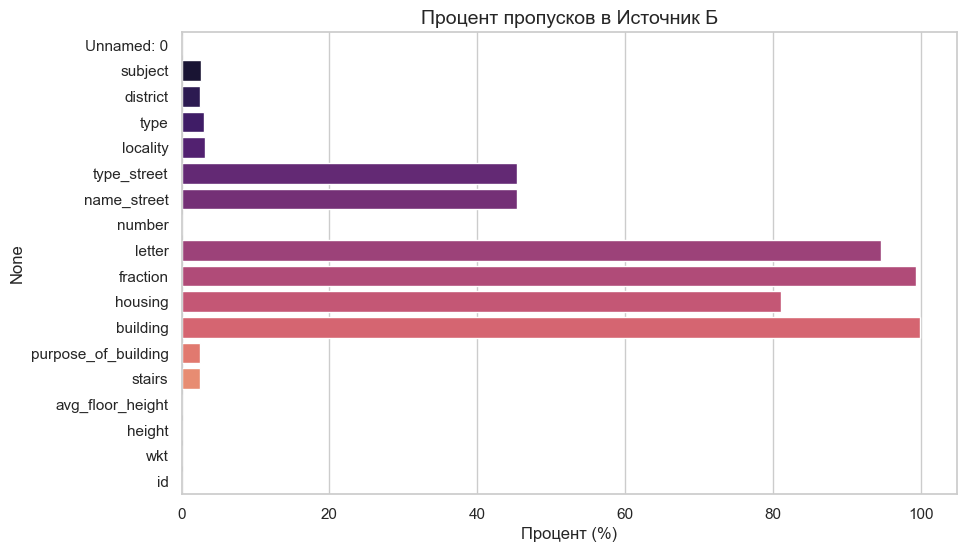

In [9]:
df_A = pd.read_csv('data/raw/cup_it_example_src_A.csv')
def basic_eda(df, name):
    print(f"\n Анализ: {name}")
    
    # Размерность
    print(f"Строк: {df.shape[0]}")
    print(f"Столбцов: {df.shape[1]}")
    
    # Типы данных и общая инфа
    print("\nТипы данных и память")
    print(df.info())
    
    # Проверка на пропуски 
    print("\n Пропущенные значения (NaN)")
    nan_counts = df.isnull().sum()
    nan_percent = (df.isnull().sum() / len(df)) * 100
    nan_df = pd.concat([nan_counts, nan_percent], axis=1, keys=['Count', 'Percent %'])
    print(nan_df[nan_df['Count'] > 0].sort_values(by='Percent %', ascending=False))
    
    # Визуализация пропусков
    plt.figure(figsize=(10, 6))
    sns.barplot(x=nan_percent.values, y=nan_percent.index, palette='magma')
    plt.title(f'Процент пропусков в {name}', fontsize=14)
    plt.xlabel('Процент (%)')
    plt.show()

# Запускаем для обоих
basic_eda(df_A, "Источник А")
basic_eda(df_B, "Источник Б")

Создадим геометрию и спарсим WKT

In [10]:
geometry = gpd.GeoSeries.from_wkt(df_B['wkt'])
gdf_B = gpd.GeoDataFrame(df_B, geometry=geometry, crs="EPSG:4326") # стандартные широта, долгота

# посмотрим сколько невалидных полигонов
invalid_before = (~gdf_B['geometry'].is_valid).sum()
print(f"Найдено невалидных полигонов до лечения: {invalid_before}")

# фиксим
gdf_B['geometry'] = gdf_B['geometry'].make_valid()

# смотрим изменение
invalid_after = (~gdf_B['geometry'].is_valid).sum()
print(f"Найдено сломанных полигонов после лечения: {invalid_after}")

print(f"Итого успешно пофикшено: {invalid_before - invalid_after} полигонов")

gdf_B = gdf_B.drop(columns=['wkt'])
print(f"Размер датасета: {gdf_B.shape}")

Найдено невалидных полигонов до лечения: 0
Найдено сломанных полигонов после лечения: 0
Итого успешно пофикшено: 0 полигонов
Размер датасета: (161076, 18)


Попытаемся найти скрытые баги геометрии нулевая площадь или пустая геометрия

In [11]:
# проверка на пустую геометрию
empty_count = gdf_B['geometry'].is_empty.sum()
print(f"Пустые геометрии (Empty): {empty_count}")

# проверка на нулевую или микро-площадь
gdf_B['area_sqm'] = gdf_B.to_crs(epsg=32636).geometry.area

# ищем вырожденные линии (< 0.1 кв.м) и будки (< 10 кв.м)
zero_area_count = (gdf_B['area_sqm'] < 0.1).sum()
micro_area_count = ((gdf_B['area_sqm'] >= 0.1) & (gdf_B['area_sqm'] < 10)).sum()

print(f"Вырожденные полигоны (площадь ~ 0): {zero_area_count}")
print(f"Микро-объекты (будки/ларьки < 10 кв.м): {micro_area_count}")

Пустые геометрии (Empty): 0
Вырожденные полигоны (площадь ~ 0): 0
Микро-объекты (будки/ларьки < 10 кв.м): 652


### Поиск аномалий в этажности и высоте
Посмотрим на распределение целевых переменных `height` и `stairs`. Нам нужно отловить "500-этажки" и здания с нулевой высотой.

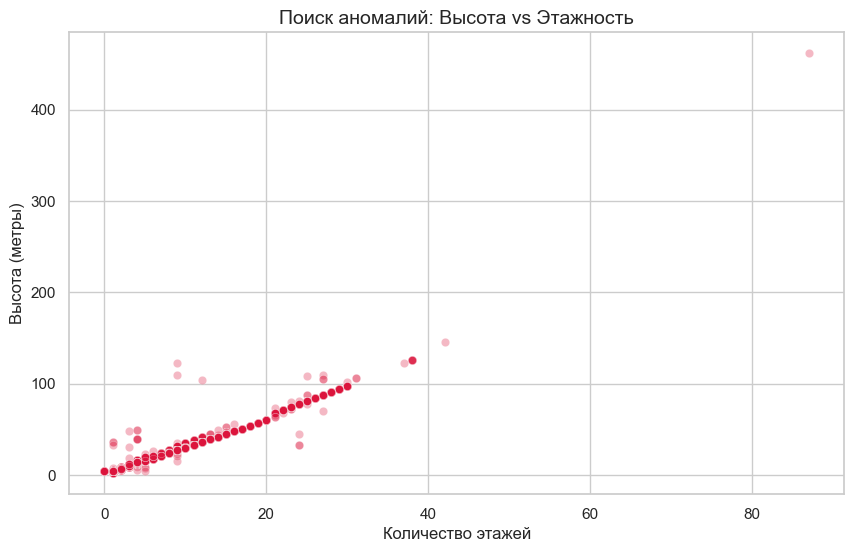

Найдено жестких выбросов (небоскребов-ошибок): 2


,id,stairs,height,avg_floor_height
27932,27933,87.0,462.0,5.0
29315,29316,NaN,462.0,0.0


In [12]:
# строим Scatter-plot: Этажи vs Высота
plt.figure(figsize=(10, 6))
sns.scatterplot(data=gdf_B, x='stairs', y='height', alpha=0.3, color='crimson')
plt.title('Поиск аномалий: Высота vs Этажность', fontsize=14)
plt.xlabel('Количество этажей', fontsize=12)
plt.ylabel('Высота (метры)', fontsize=12)
plt.show()

# смотрим на аномалии
crazy_buildings = gdf_B[(gdf_B['stairs'] > 50) | (gdf_B['height'] > 200)]
print(f"Найдено жестких выбросов (небоскребов-ошибок): {len(crazy_buildings)}")
display(crazy_buildings[['id', 'stairs', 'height', 'avg_floor_height']].head())

In [15]:
# Создаем маску для поиска ошибочных данных
error_mask = (
    (gdf_B['height'] == 0) | 
    (gdf_B['stairs'] > 40) | 
    (gdf_B['height'] > 150) | 
    (gdf_B['avg_floor_height'] < 2.2) | 
    (gdf_B['avg_floor_height'] > 6.0)
)

errors_gdf = gdf_B[error_mask].copy()
print(f"Всего ошибочных зданий для карты: {len(errors_gdf)}")

# Вытаскиваем координаты центроиды полигонов
errors_gdf['lat'] = errors_gdf.geometry.centroid.y
errors_gdf['lon'] = errors_gdf.geometry.centroid.x

# Очищаем от NaN координат
errors_gdf = errors_gdf.dropna(subset=['lat', 'lon'])

m = folium.Map(location=[59.9343, 30.3351], zoom_start=10, tiles='CartoDB dark_matter')

heat_data = [[row['lat'], row['lon']] for index, row in errors_gdf.iterrows()]
# Используем стандартный градиент для соответствия легенде
HeatMap(heat_data, radius=12, blur=10, gradient={0.4: 'blue', 0.65: 'yellow', 1: 'red'}).add_to(m)

legend_html = '''
     <div style="position: fixed; 
     bottom: 50px; left: 50px; width: 280px; height: 220px; 
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color: white; opacity: 0.9;
     padding: 15px;
     border-radius: 10px;
     font-family: 'Arial', sans-serif;
     ">
     <b>Анализ качества данных (Б)</b><br>
     <div style="margin-top: 10px; margin-bottom: 5px;"><i>Плотность аномалий на карте:</i></div>
     
     <div style="
         background: linear-gradient(to right, blue, cyan, green, yellow, orange, red);
         width: 100%;
         height: 15px;
         border-radius: 5px;
         margin-bottom: 5px;
     "></div>
     <div style="display: flex; justify-content: space-between; font-size: 10px; color: #555;">
         <span>Низкая</span>
         <span>Средняя</span>
         <span>Критическая</span>
     </div>

     <hr style="margin: 10px 0;">
     
     <b>Критерии фильтрации:</b><br>
     <div style="font-size: 12px; line-height: 1.6;">
         • Высота: 0м или > 150м<br>
         • Этажность: > 40 этажей<br>
         • Ошибки в высоте этажа (2.2-6м)<br>
         • Нулевая площадь полигона
     </div>
     
     <div style="margin-top: 10px; font-weight: bold; color: crimson;">
         Найдено объектов: ''' + str(len(errors_gdf)) + '''
     </div>
     </div>
     '''

m.get_root().html.add_child(folium.Element(legend_html))

m.save('data/processed/spatial_error_heatmap_v2.html')


Всего ошибочных зданий для карты: 4278


C:\Users\User\AppData\Local\Temp\ipykernel_19264\2832961881.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  errors_gdf['lat'] = errors_gdf.geometry.centroid.y
C:\Users\User\AppData\Local\Temp\ipykernel_19264\2832961881.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  errors_gdf['lon'] = errors_gdf.geometry.centroid.x


Построим наш хитмап в сиаборне и плт

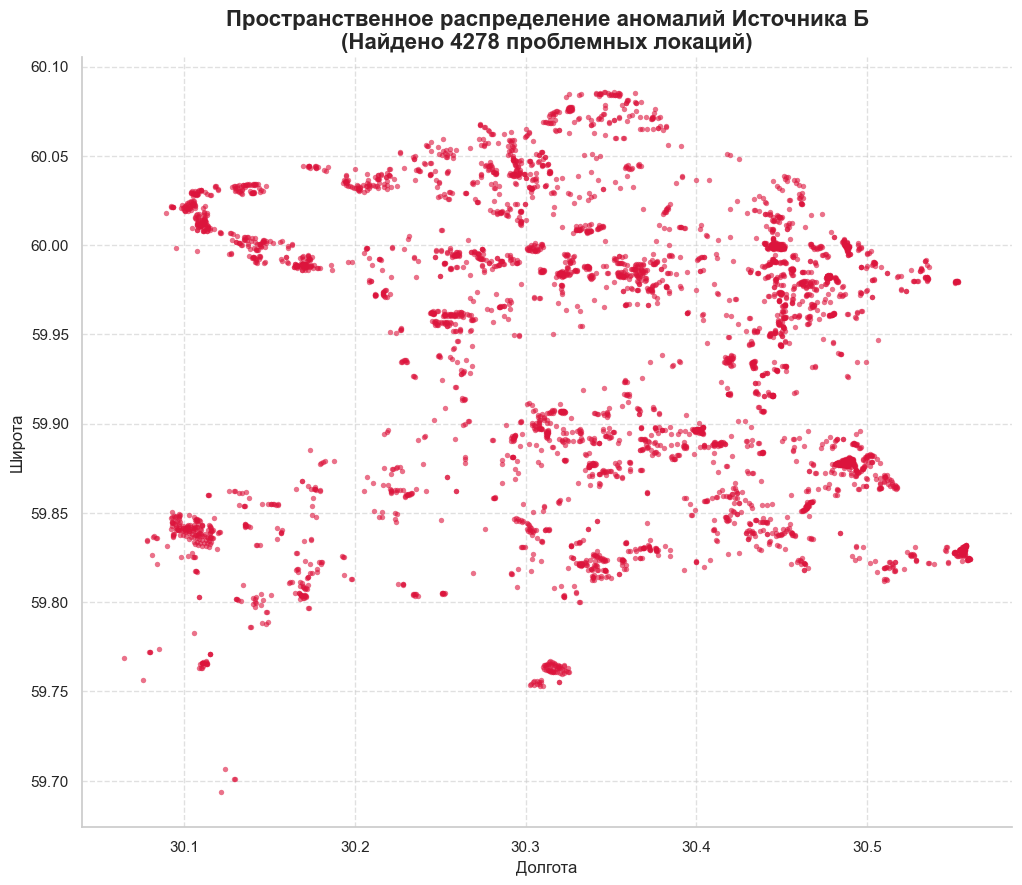

In [16]:
plt.figure(figsize=(12, 10))

# x = долгота, y = широта
sns.scatterplot(
    data=errors_gdf, 
    x='lon', 
    y='lat', 
    color='crimson', 
    s=15, 
    alpha=0.6,
    linewidth=0
)

plt.title(f'Пространственное распределение аномалий Источника Б\n(Найдено {len(errors_gdf)} проблемных локаций)', fontsize=16, fontweight='bold')
plt.xlabel('Долгота', fontsize=12)
plt.ylabel('Широта', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

sns.despine()

plt.savefig('static_error_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

## EDA для датасета A

In [19]:
file_path_a = 'data/raw/cup_it_example_src_A.csv'
df_a = pd.read_csv(file_path_a)

print("\n 1. Общая информация и пропуски")
print(f"Всего строк: {len(df_a)}")
print("\nКоличество Nan по колонкам:")
print(df_a.isnull().sum())

print("\n2. Анализ атрибутов - ищем мусор")
# Смотрим топ-5 типов зданий
print("Топ-5 тегов (типов объектов):")
print(df_a['tags'].value_counts().head(5))

# Смотрим аномалии по площади
print("\nСтатистика по площади (area_sq_m):")
print(f"Минимальная площадь: {df_a['area_sq_m'].min()} кв.м.")
print(f"Максимальная площадь: {df_a['area_sq_m'].max()} кв.м.")
print(f"Объектов меньше 20 кв.м.: {(df_a['area_sq_m'] < 20).sum()}")

print("\n3. Анализ геометрии")
df_a['geometry'] = gpd.GeoSeries.from_wkt(df_a['geometry'])
gdf_a = gpd.GeoDataFrame(df_a, geometry='geometry')

# Ищем невалидную геометрию
invalid_geom = ~gdf_a.is_valid
empty_geom = gdf_a.is_empty

print(f"Невалидных полигонов: {invalid_geom.sum()}")
print(f"Пустых полигонов: {empty_geom.sum()}")


 1. Общая информация и пропуски
Всего строк: 171454

Количество Nan по колонкам:
Unnamed: 0                  0
id                          0
title                  164097
tags                        0
geometry                    0
area_sq_m                   0
gkh_address            153215
gkh_floor_count_min    154161
gkh_floor_count_max    153822
dtype: int64

2. Анализ атрибутов - ищем мусор
Топ-5 тегов (типов объектов):
tags
['жилое здание']                       58297
['постройка, сооружение']              48218
['промышленность']                     22565
['бизнес и услуги']                     7768
['Комплекс зданий', 'жилое здание']     5428
Name: count, dtype: int64

Статистика по площади (area_sq_m):
Минимальная площадь: 0.3057499998183339 кв.м.
Максимальная площадь: 137682.43829999957 кв.м.
Объектов меньше 20 кв.м.: 17868

3. Анализ геометрии
Невалидных полигонов: 0
Пустых полигонов: 0


Попытаемся найти скрытые баги геометрии дубликаты по координатам пересечения разных объектов 

In [22]:
file_path_a = 'data/raw/cup_it_example_src_A.csv'
df_a = pd.read_csv(file_path_a)

df_a['geometry'] = gpd.GeoSeries.from_wkt(df_a['geometry'])
gdf_a = gpd.GeoDataFrame(df_a, geometry='geometry')

# Поиск абсолютных дубликатов по координатам
exact_duplicates_a = gdf_a['geometry'].duplicated().sum()
print(f"Полных дубликатов геометрии: {exact_duplicates_a}")

# Поиск нахлестов 
overlaps_a = gpd.sjoin(gdf_a, gdf_a, how='inner', predicate='intersects')

# Убираем пересечения полигона самого с собой
real_overlaps_a = overlaps_a[overlaps_a.index != overlaps_a['index_right']]

# Считаем, сколько уникальных зданий имеют нахлесты
overlapping_buildings_count_a = real_overlaps_a.index.nunique()
print(f"Зданий, которые накладываются или пересекаются с другими: {overlapping_buildings_count_a}")

Полных дубликатов геометрии: 0
Зданий, которые накладываются или пересекаются с другими: 86040


ищем врущую площадь и вытянутые объекты - потенциально заборы 

In [23]:
# Задаем градусы и переводим в метры для Питера 
gdf_a.set_crs(epsg=4326, inplace=True, allow_override=True)
gdf_a_metric = gdf_a.to_crs(epsg=32636)

# Проверка расхождения площадей
# Считаем реальную площадь полигонов в квадратных метрах
gdf_a['real_area'] = gdf_a_metric.geometry.area

# Ищем здания, где заявленная площадь отличается от реальной больше чем на 10%
area_diff = abs(gdf_a['real_area'] - gdf_a['area_sq_m']) / gdf_a['area_sq_m']
fake_areas = (area_diff > 0.10).sum()
print(f"Зданий с врущей площадью (расхождение > 10%): {fake_areas}")

# Ищем заборы и дороги - аномально вытянутые объекты
# Коэффициент формы = (Периметр^2) / Площадь. У квадрата он прмиерно 16, у длинной нити - огромный
gdf_a['form_factor'] = (gdf_a_metric.geometry.length ** 2) / gdf_a_metric.geometry.area
# Возьмем порог 100 
fences = (gdf_a['form_factor'] > 100).sum()
print(f"Аномально вытянутых объектов (похоже на заборы/дороги): {fences}")

# Проверка битых тегов
# Ищем строки, которые не начинаются с '[' или не заканчиваются на ']'
broken_tags = gdf_a[~gdf_a['tags'].str.match(r'^\[.*\]$')]
print(f"Строк с поломанным синтаксисом тегов: {len(broken_tags)}")
# Ищем пустые списки
empty_tags = (gdf_a['tags'] == '[]').sum()
print(f"Объектов вообще без тегов: {empty_tags}")

Зданий с врущей площадью (расхождение > 10%): 0
Аномально вытянутых объектов (похоже на заборы/дороги): 1938
Строк с поломанным синтаксисом тегов: 0
Объектов вообще без тегов: 0


## Эвристика: Фильтрация линейных объектов (заборы, дороги) через пространственную эрозию

В сырых данных часто встречаются объекты, которые имеют тег здания, но фактически являются линейными сооружениями (заборы, подпорные стенки, элементы дорожной инфраструктуры). Оставлять их в обучающей выборке нельзя.

**Алгоритм выявления:**
Используется метод морфологической эрозии (negative buffer). Полигоны сужаются на 2.5 метра внутрь. 
* Если это реальное здание (ширина > 5 метров), его геометрия просто уменьшится. 
* Если это линейный объект (ширина < 5 метров), его геометрия полностью "схлопнется" (станет `empty`).

Этот шаг позволяет алгоритмически отсеять пространственный шум.

In [24]:
# Применяем отрицательный буфер (-2.5 метра)
# Если полигон тоньше 5 метров (2.5 + 2.5), он исчезнет
eroded_geoms = gdf_a_metric.geometry.buffer(-2.5)

# Находим те объекты, которые полностью схлопнулись 
is_fence_or_road = eroded_geoms.is_empty

# Считаем, сколько таких тонких объектов мы поймали
print(f"Найдено заборов/дорог (слишком узкие для зданий): {is_fence_or_road.sum()}")

# Посмотрим теги у этих узких объектов
print(gdf_a_metric[is_fence_or_road]['tags'].value_counts())

Найдено заборов/дорог (слишком узкие для зданий): 40246
tags
['постройка, сооружение']                      19118
['жилое здание']                               11012
['торговля']                                    2433
['промышленность']                              1802
['бизнес и услуги']                             1358
                                               ...  
['научное учреждение, НИИ', 'офисы']               1
['кассы', 'транспорт']                             1
['ткани, товары для рукоделия', 'торговля']        1
['беседка', 'культура и отдых']                    1
['транспорт, перевозки', 'транспорт']              1
Name: count, Length: 121, dtype: int64


* Посмотрим соотношение домов с высотой и без 
* Посмотрим на распределение высот домов 

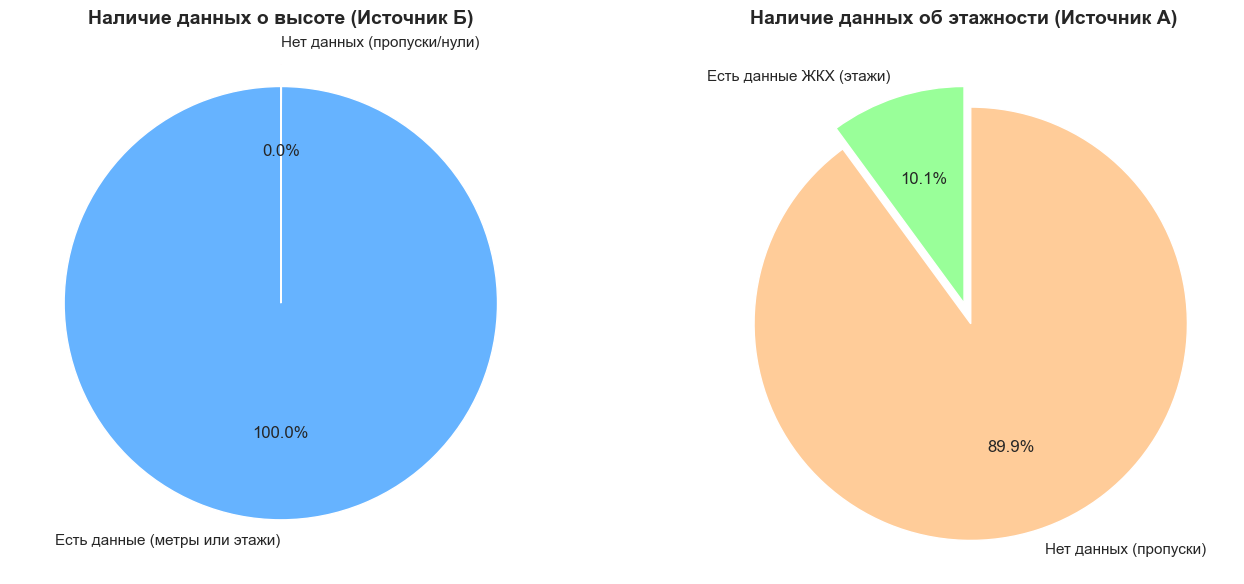

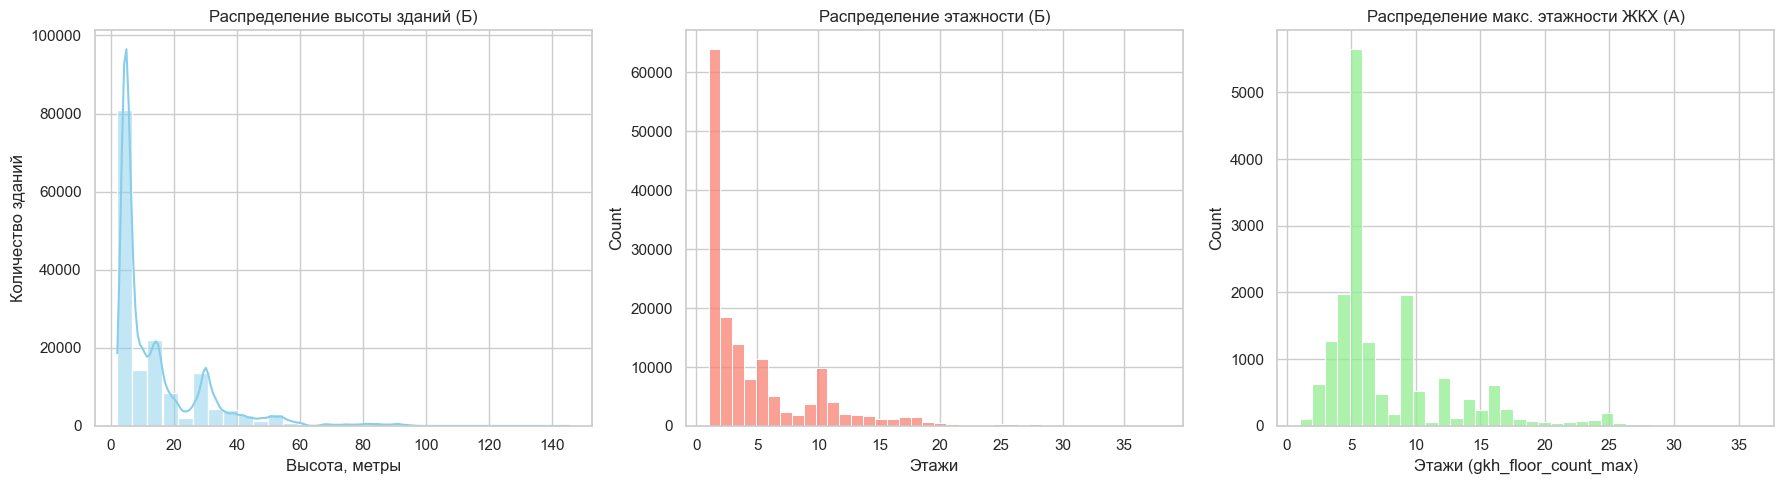

--- Статистика по Источнику Б ---
Медианная высота (метры): 6.6
Медианная этажность: 2.0

--- Статистика по Источнику А ---
Медианная этажность (ЖКХ): 5.0


In [25]:
# Считаем соотношение домов с высотой и без 

# В Источнике Б проверяем наличие height (метры) и stairs (этажи). Исключаем нули.
df_B['has_height'] = df_B['height'].notna() & (df_B['height'] > 0)
df_B['has_stairs'] = df_B['stairs'].notna() & (df_B['stairs'] > 0)
df_B['has_any_info'] = df_B['has_height'] | df_B['has_stairs']

# В Источнике А смотрим на данные "Реформы ЖКХ"
df_A['has_gkh_info'] = df_A['gkh_floor_count_max'].notna() & (df_A['gkh_floor_count_max'] > 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Пай-чарт для Источника Б
sizes_B = [df_B['has_any_info'].sum(), (~df_B['has_any_info']).sum()]
axes[0].pie(sizes_B, labels=['Есть данные (метры или этажи)', 'Нет данных (пропуски/нули)'], 
            autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90, explode=[0, 0.1])
axes[0].set_title('Наличие данных о высоте (Источник Б)', fontsize=14, fontweight='bold')

# Пай-чарт для Источника А
sizes_A = [df_A['has_gkh_info'].sum(), (~df_A['has_gkh_info']).sum()]
axes[1].pie(sizes_A, labels=['Есть данные ЖКХ (этажи)', 'Нет данных (пропуски)'], 
            autopct='%1.1f%%', colors=['#99ff99','#ffcc99'], startangle=90, explode=[0, 0.1])
axes[1].set_title('Наличие данных об этажности (Источник А)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
# 2. Смотрим на распределение высот и этажности

# Отсекаем жесткие выбросы, чтобы график был читаемым
valid_heights_B = df_B[(df_B['height'] > 0) & (df_B['height'] <= 150)]['height']
valid_stairs_B = df_B[(df_B['stairs'] > 0) & (df_B['stairs'] <= 40)]['stairs']
valid_floors_A = df_A[(df_A['gkh_floor_count_max'] > 0) & (df_A['gkh_floor_count_max'] <= 40)]['gkh_floor_count_max']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма высоты в метрах (Источник Б)
sns.histplot(valid_heights_B, bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение высоты зданий (Б)', fontsize=12)
axes[0].set_xlabel('Высота, метры')
axes[0].set_ylabel('Количество зданий')

# Гистограмма этажности (Источник Б)
sns.histplot(valid_stairs_B, bins=int(valid_stairs_B.max()), ax=axes[1], color='salmon')
axes[1].set_title('Распределение этажности (Б)', fontsize=12)
axes[1].set_xlabel('Этажи')

# Гистограмма этажности ЖКХ (Источник А)
sns.histplot(valid_floors_A, bins=int(valid_floors_A.max() if not valid_floors_A.empty else 1), ax=axes[2], color='lightgreen')
axes[2].set_title('Распределение макс. этажности ЖКХ (А)', fontsize=12)
axes[2].set_xlabel('Этажи (gkh_floor_count_max)')

plt.tight_layout()
plt.show()


# 3. Базовая статистика 
print("--- Статистика по Источнику Б ---")
print(f"Медианная высота (метры): {valid_heights_B.median():.1f}")
print(f"Медианная этажность: {valid_stairs_B.median():.1f}")

print("\n--- Статистика по Источнику А ---")
print(f"Медианная этажность (ЖКХ): {valid_floors_A.median():.1f}")

## Итоги разведочного анализа (EDA)

По результатам первичного анализа источников А (ЖКХ) и Б (Кадастр) зафиксированы следующие инсайты:

1. **Зашумленность целевых признаков:** В сырых данных присутствует критический процент логических аномалий (гаражи высотой 100+ метров, экстремальная этажность в базовых категориях). Датасет будет в следующем ноутбуке очищен от жестких выбросов, линейных объектов (заборы/дороги).
2. **Разметка пропусков:** Значительная часть объектов не имеет заполненных атрибутов этажности и высоты, что потребует использования методов заполнения пропусков на следующем этапе.

**Дальнейший план:** Очищенные геометрии передаются на следующий этап пайплайна (`02_Merging_and_Feature_Engineering.ipynb`). Будет произведено пространственное слияние слоев, расчет площадей перекрытия и генерация новых признаков (плотность застройки, агрегированные метрики соседей) для подготовки обучающей выборки.